# Frequency analysis of calcium traces


In [2]:
import numpy as np
from scipy.fft import rfft, rfftfreq
from scipy.signal import  detrend
from scipy.signal.windows import blackman  # Corrected sub-module
import matplotlib.pyplot as plt

In [ ]:
#%% Modify the following
main_dir = "/Volumes/tungsten/scratch/gfelsenb/Hanna/2p-imaging/Hanna/"
container_id = 'PPL101'
day_id = "2026_03_04"
fly_id = 'fly1'



# Load the signal
trace = [] # We need the part of the trace that oscillates (e.g. if stimulus presentation is the only oscillating part it should be isolated for analysis)

# --- Parameters ---
N = len(trace)
fs = [] # sampling frequency of the trace


In [ ]:
# Detrending against bleaching
# Linear detrend is better than mean subtraction for bleaching
trace_detrended = detrend(trace)
plt.plot(trace_detrended)


In [ ]:
# Window to mitigate spectral leakage (since signal is not perfectly periodic)
w = blackman(N)
yf = rfft(trace_detrended * w)

# 2. Correct Frequency Axis
# why rfftfreq? it automatically handles the N//2 logic
xf = rfftfreq(N, d=1/fs)

# 3. Normalized Amplitude (Correcting for Blackman Window reduction of signal energy)
# Window gain correction: 2.0 / np.sum(w)
amplitude_spectrum = (2.0 / np.sum(w)) * np.abs(yf)

Plot the power spectrum

In [ ]:
time_axis = np.arange(N) / fs

# --- Start Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

# Top Panel: Time Domain
ax1.plot(time_axis, trace, color='gray', alpha=0.4, label='Raw Trace')
ax1.plot(time_axis, trace_detrended, color='black', label='Detrended')
ax1.set_title(f"Time-Domain Signal", fontsize=14)
ax1.set_ylabel("$\Delta F/F$")
ax1.set_xlabel("Time (s)")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.2)

# Bottom Panel: Frequency Domain
ax2.plot(xf, amplitude_spectrum, color='crimson', linewidth=1.5)

ax2.set_title("Amplitude Spectrum", fontsize=14)
ax2.set_ylabel("Amplitude ($\Delta F/F$)")
ax2.set_xlabel("Frequency (Hz)")
ax2.set_xlim(0, fs/2)  # Nyquist Limit
ax2.set_ylim(0, np.max(amplitude_spectrum) * 1.1)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

Take the power @ the frequency of interest

In [ ]:
freq_of_interest = []
req_idx = np.argmin(np.abs(xf - freq_of_interest))
power_at_hz = amplitude_spectrum[req_idx]


## Testing the analysis with mock data

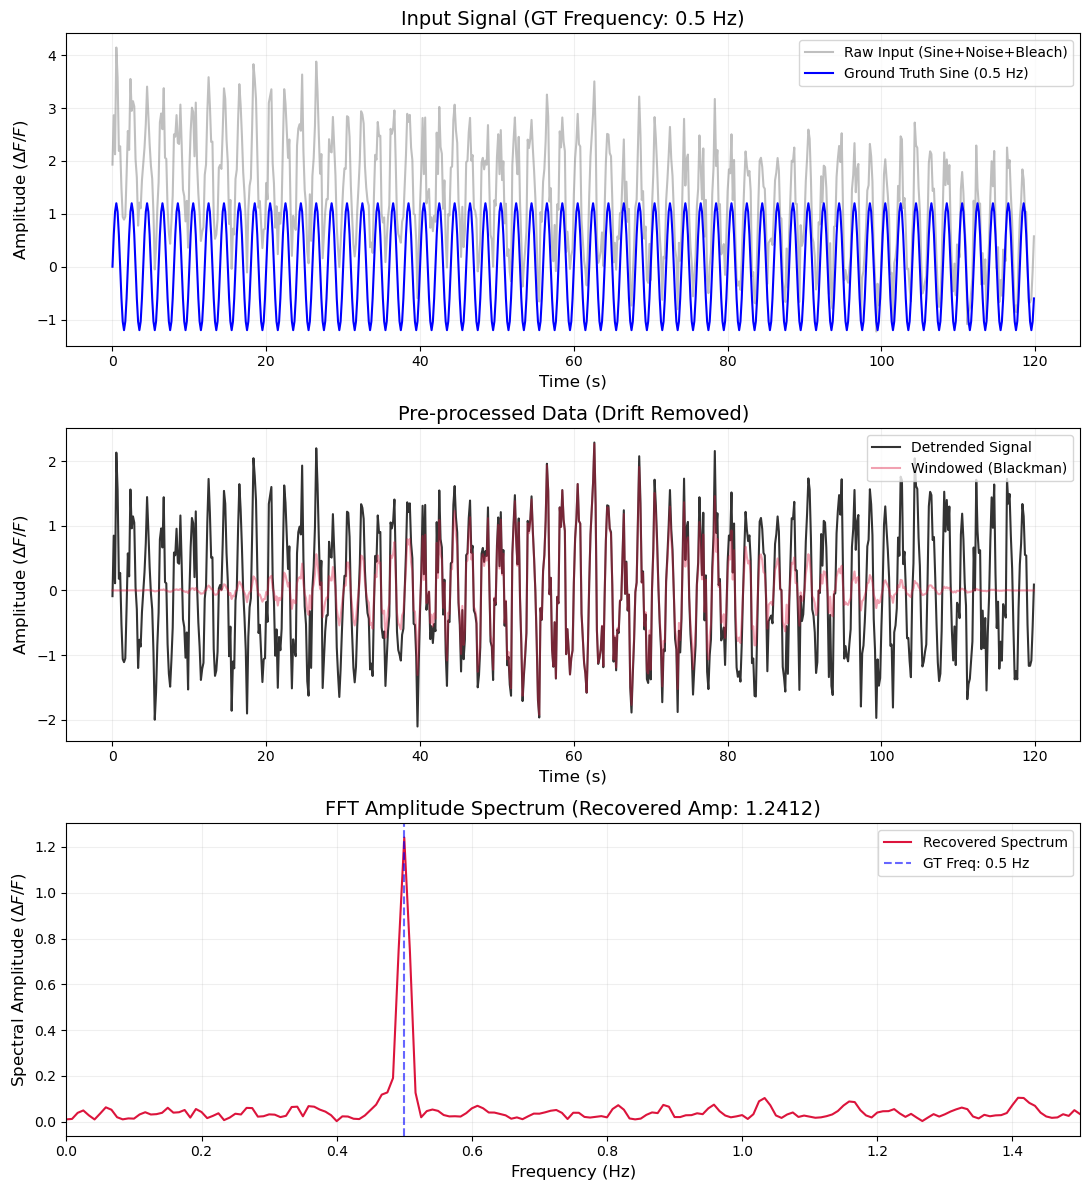

--- Results ---
Ground Truth Frequency: 0.5 Hz
Ground Truth Amplitude: 1.2
Recovered Amplitude:    1.2412
Error Magnitude:        0.0412


In [7]:
def run_labeled_fft_test():
    # 1. Define Ground Truth Parameters
    fs = 6.0              # Target resampling rate (Hz)
    duration = 120        # Duration in seconds
    N = int(fs * duration)
    gt_freq = 0.5         # Ground Truth Frequency (Hz)
    gt_amp = 1.2          # Ground Truth Amplitude (Delta F/F)
    
    # 2. Generate Synthetic Data
    t = np.arange(N) / fs
    clean_sine = gt_amp * np.sin(2 * np.pi * gt_freq * t)
    noise = np.random.normal(0, 0.4, N)  # Gaussian noise
    bleaching = np.linspace(2.0, 0.5, N) # Linear decay drift
    
    # Received signal
    input_trace = clean_sine + noise + bleaching
    
    # 3. Processing Pipeline
    trace_detrended = detrend(input_trace)
    w = blackman(N)
    yf = rfft(trace_detrended * w)
    xf = rfftfreq(N, 1/fs)
    
    # Window Gain Correction: 2.0 / np.sum(w)
    amplitude_spectrum = (2.0 / np.sum(w)) * np.abs(yf)
    
    # 4. Result Extraction
    idx = np.argmin(np.abs(xf - gt_freq))
    recovered_amp = amplitude_spectrum[idx]
    
    # --- Visualization ---
    fig, axes = plt.subplots(3, 1, figsize=(11, 12))
    
    # Panel 1: Raw Input Signal
    axes[0].plot(t, input_trace, color='gray', alpha=0.5, label='Raw Input (Sine+Noise+Bleach)')
    axes[0].plot(t, clean_sine, color='blue', linewidth=1.5, label=f'Ground Truth Sine ({gt_freq} Hz)')
    axes[0].set_title(f"Input Signal (GT Frequency: {gt_freq} Hz)", fontsize=14)
    axes[0].set_xlabel("Time (s)", fontsize=12)
    axes[0].set_ylabel("Amplitude ($\Delta F/F$)", fontsize=12)
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.2)

    # Panel 2: Pre-processed Signal
    axes[1].plot(t, trace_detrended, color='black', alpha=0.8, label='Detrended Signal')
    axes[1].plot(t, trace_detrended * w, color='crimson', alpha=0.4, label='Windowed (Blackman)')
    axes[1].set_title("Pre-processed Data (Drift Removed)", fontsize=14)
    axes[1].set_xlabel("Time (s)", fontsize=12)
    axes[1].set_ylabel("Amplitude ($\Delta F/F$)", fontsize=12)
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.2)

    # Panel 3: Amplitude Spectrum
    axes[2].plot(xf, amplitude_spectrum, color='crimson', linewidth=1.5, label='Recovered Spectrum')
    axes[2].axvline(gt_freq, color='blue', linestyle='--', alpha=0.6, label=f'GT Freq: {gt_freq} Hz')
    axes[2].set_title(f"FFT Amplitude Spectrum (Recovered Amp: {recovered_amp:.4f})", fontsize=14)
    axes[2].set_xlabel("Frequency (Hz)", fontsize=12)
    axes[2].set_ylabel("Spectral Amplitude ($\Delta F/F$)", fontsize=12)
    axes[2].set_xlim(0, 1.5) # Focus on frequencies of interest
    axes[2].legend()
    axes[2].grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.show()

    print(f"--- Results ---")
    print(f"Ground Truth Frequency: {gt_freq} Hz")
    print(f"Ground Truth Amplitude: {gt_amp}")
    print(f"Recovered Amplitude:    {recovered_amp:.4f}")
    print(f"Error Magnitude:        {abs(gt_amp - recovered_amp):.4f}")

run_labeled_fft_test()

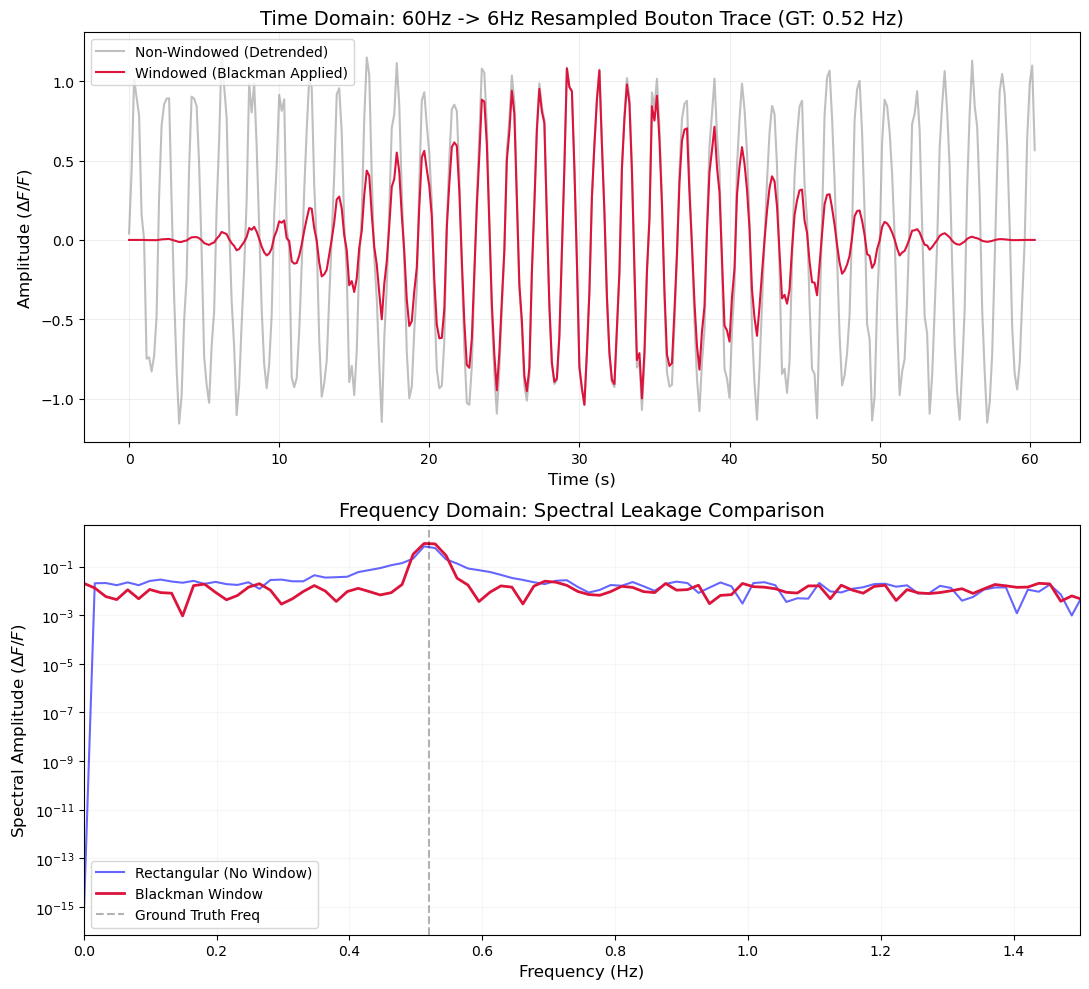

In [6]:


def compare_windowing_test():
    # 1. Setup Parameters
    fs = 6.0
    duration = 60.5 # Fractional duration to force spectral leakage
    N = int(fs * duration)
    t = np.arange(N) / fs
    
    gt_freq = 0.52 # Off-bin frequency to show leakage
    gt_amp = 1.0
    
    # 2. Synthetic Trace (Sine + low noise + drift)
    clean_sine = gt_amp * np.sin(2 * np.pi * gt_freq * t)
    input_trace = clean_sine + np.random.normal(0, 0.1, N) + np.linspace(0, 1, N)
    
    # 3. Processing Pipeline
    trace_processed = detrend(input_trace)
    xf = rfftfreq(N, 1/fs)
    
    # --- NO WINDOW (Rectangular) ---
    yf_none = rfft(trace_processed)
    # Normalization for Rectangular is 2/N
    amp_none = (2.0 / N) * np.abs(yf_none)
    
    # --- WITH WINDOW (Blackman) ---
    w = blackman(N)
    yf_wind = rfft(trace_processed * w)
    # Normalization for Windowed is 2/sum(w)
    amp_wind = (2.0 / np.sum(w)) * np.abs(yf_wind)
    
    # --- Visualization ---
    fig, axes = plt.subplots(2, 1, figsize=(11, 10))
    
    # Top: Time Domain comparison
    axes[0].plot(t, trace_processed, color='gray', alpha=0.5, label='Non-Windowed (Detrended)')
    axes[0].plot(t, trace_processed * w, color='crimson', label='Windowed (Blackman Applied)')
    axes[0].set_title(f"Time Domain: 60Hz -> 6Hz Resampled Bouton Trace (GT: {gt_freq} Hz)", fontsize=14)
    axes[0].set_xlabel("Time (s)", fontsize=12)
    axes[0].set_ylabel("Amplitude ($\Delta F/F$)", fontsize=12)
    axes[0].legend()
    axes[0].grid(True, alpha=0.2)
    
    # Bottom: Frequency Domain comparison
    axes[1].plot(xf, amp_none, color='blue', alpha=0.6, label='Rectangular (No Window)')
    axes[1].plot(xf, amp_wind, color='crimson', linewidth=2, label='Blackman Window')
    axes[1].axvline(gt_freq, color='black', linestyle='--', alpha=0.3, label='Ground Truth Freq')
    
    axes[1].set_title("Frequency Domain: Spectral Leakage Comparison", fontsize=14)
    axes[1].set_xlabel("Frequency (Hz)", fontsize=12)
    axes[1].set_ylabel("Spectral Amplitude ($\Delta F/F$)", fontsize=12)
    axes[1].set_xlim(0, 1.5)
    axes[1].set_yscale('log') # Log scale makes leakage (sidelobes) very visible
    axes[1].legend()
    axes[1].grid(True, which="both", ls="-", alpha=0.1)
    
    plt.tight_layout()
    plt.show()

compare_windowing_test()